# HCMUT EE MACHINE LEARNING & IOT
## BTVN Buổi 2: Xác suất thống kê cho AI

Môn học: Python & Machine Learning

Sinh viên: Nguyễn Bá Quốc Long

MSSV: 2550137


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### Phần 1

In [2]:
# 1.1
df = sns.load_dataset("iris")
display(df.head())
print(df.shape)
print(f'Dữ liệu có {df.shape[0]} hàng và {df.shape[1]} cột')
print(f'Các kiểu dữ liệu của các cột:')
print(df.dtypes)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


(150, 5)
Dữ liệu có 150 hàng và 5 cột
Các kiểu dữ liệu của các cột:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object


In [3]:
# 1.2
df_filtered = df.loc[:, 'sepal_length':'petal_width']
df_calculation = pd.DataFrame({
    'Mean': df_filtered.mean(axis=0).round(1),
    'Median': np.median(df_filtered, axis=0),
    'Mode': df_filtered.mode(axis=0).iloc[0],
    'Var': df_filtered.var(axis=0).round(1),
    'Std': df_filtered.std(axis=0).round(1),
    'Max': df_filtered.max(axis=0).round(1),
    'Min': df_filtered.min(axis=0).round(1),
    'Q1': df_filtered.quantile(1/4),
    'Q3': df_filtered.quantile(3/4),
    'IQR': (df_filtered.quantile(3/4) - df_filtered.quantile(1/4)).round(1)
})
display(df_calculation.head())

,Mean,Median,Mode,Var,Std,Max,Min,Q1,Q3,IQR
sepal_length,5.8,5.80,5.0,0.7,0.8,7.9,4.3,5.1,6.4,1.3
sepal_width,3.1,3.00,3.0,0.2,0.4,4.4,2.0,2.8,3.3,0.5
petal_length,3.8,4.35,1.4,3.1,1.8,6.9,1.0,1.6,5.1,3.5
petal_width,1.2,1.30,0.2,0.6,0.8,2.5,0.1,0.3,1.8,1.5


In [4]:
# 1.3
df_calc_2 = df.groupby("species", observed= True).agg(
    mean_sep_len = ('sepal_length', 'mean'),
    mean_sep_width = ('sepal_width', 'mean'),
    mean_pet_len = ('petal_length', 'mean'),
    mean_pet_width = ('petal_width', 'mean'),
    std_sep_len = ('sepal_length', 'std'),
    std_sep_width = ('sepal_width', 'std'),
    std_pet_len = ('petal_length', 'std'),
    std_pet_width = ('petal_width', 'std')).round(2)
df_calc_2

,mean_sep_len,mean_sep_width,mean_pet_len,mean_pet_width,std_sep_len,std_sep_width,std_pet_len,std_pet_width
species,,,,,,,,
setosa,5.01,3.43,1.46,0.25,0.35,0.38,0.17,0.11
versicolor,5.94,2.77,4.26,1.33,0.52,0.31,0.47,0.20
virginica,6.59,2.97,5.55,2.03,0.64,0.32,0.55,0.27


Đối với em, nhóm setosa khác biệt rõ nhất.
* Xét về petal, mean và std nhìn chung thấp đáng kể so với hai loài còn lại.
* Xét về nhóm sepal và petal trong std, ở nhóm setosa, giá trị của length và width tại mỗi nhóm khá tương đồng, chênh lệch không quá lớn (Sepal: 0.03, Petal: 0.06). Ở hai nhóm còn lại, độ chênh lệch giữa hai giá trị tại mỗi nhóm khá lớn (khoảng 0.25).
* Trong khi những mục khác thì thứ tự từ nhỏ nhất đến lớn nhất là setosa $\rightarrow$ versicolor $\rightarrow$ virginica thì về sepal width, setosa lại đứng đầu và hơn cả hai nhóm một khoảng khá xa xét về cả mean và std.

### Phần 2

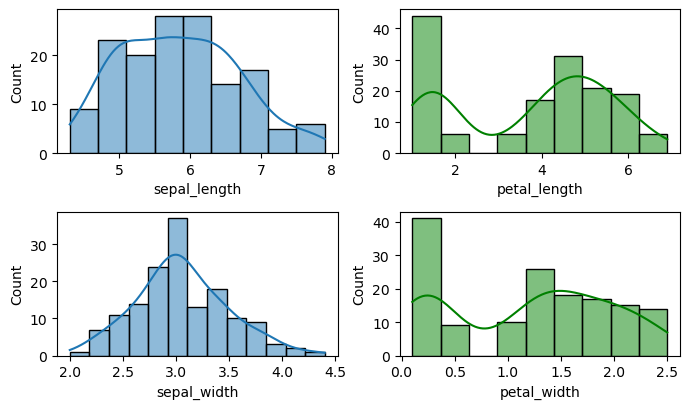

In [5]:
fig, axes = plt.subplots(nrows = 2, ncols = 2, figsize=(7, 4.2))
sns.histplot(df_filtered, x = 'sepal_length', kde= True, ax= axes[0][0])
sns.histplot(df_filtered, x = 'sepal_width', kde= True, ax= axes[1][0])
sns.histplot(df_filtered, x = 'petal_length', kde= True, ax= axes[0][1], color= 'green')
sns.histplot(df_filtered, x = 'petal_width', kde= True, ax= axes[1][1], color= 'green')
plt.tight_layout()
plt.show()

Sepal_length: đồ thị lệch trái, đỉnh rộng (do tại giá trị từ 5-6, đường KDE gần như một đường thẳng).

Sepal_width: đồ thị lệch trái, đỉnh nhọn, gần giống với phân phối chuẩn.

Petal_length & petal_width: đồ thị có 2 đỉnh

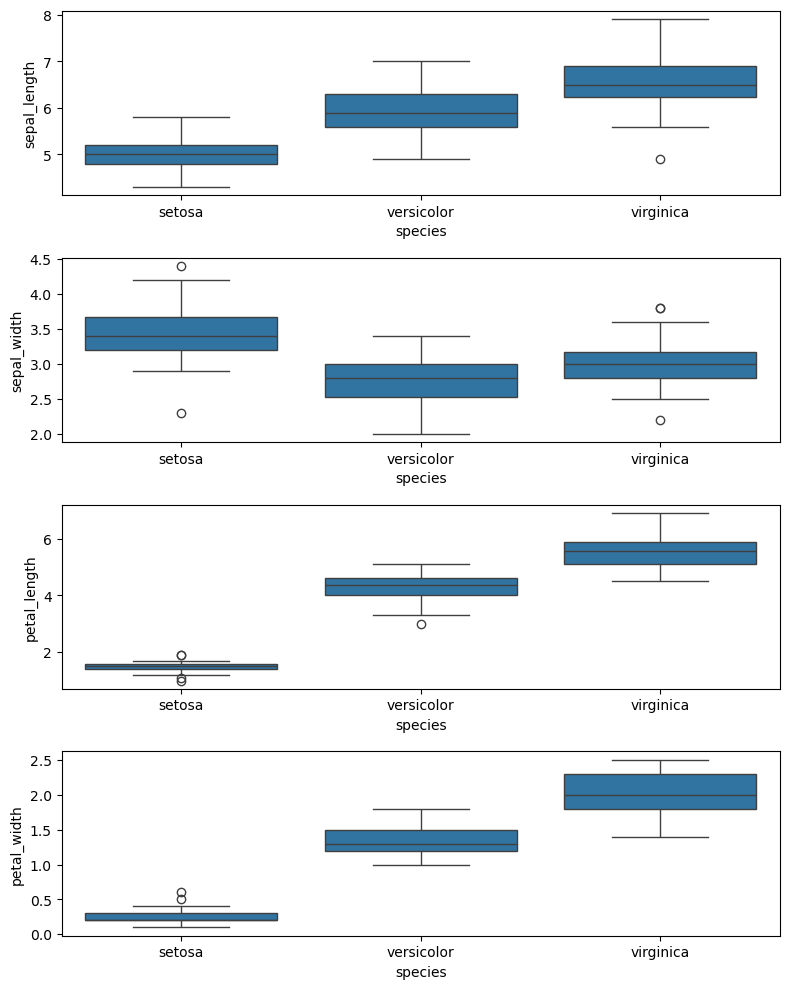

In [6]:
fig, axes = plt.subplots(nrows = 4, ncols = 1, figsize=(8, 10))
sns.boxplot(df, x = 'species', y = 'sepal_length', ax = axes[0])
sns.boxplot(df, x = 'species', y = 'sepal_width', ax = axes[1])
sns.boxplot(df, x = 'species', y = 'petal_length', ax = axes[2])
sns.boxplot(df, x = 'species', y = 'petal_width', ax = axes[3])
plt.tight_layout()
plt.show()

Quan sát từ các đồ thị, nhóm setosa có nhiều outlier nhất tại petal (3 outliers tại length và 2 outliers tại width) khiến cho mean và std bị lệch nhiều so với hai nhóm còn lại. Cũng tại petal, nhóm setal có bộ giá trị lan rộng ít nhất khiến cho hộp nhỏ và hẹp nhất (đáng kể so với hai nhóm còn lại). Về nhóm sepal, nhóm virginica có 1 outlier tại length và hai cái tại width, còn nhóm sepal thì có hai outlier tại width, với outlier dưới lệch rõ so với Q1.
Bên cạnh đó, nhóm setosa luôn nằm ở vị trí thấp nhất trừ sepal_width (đứng đầu).

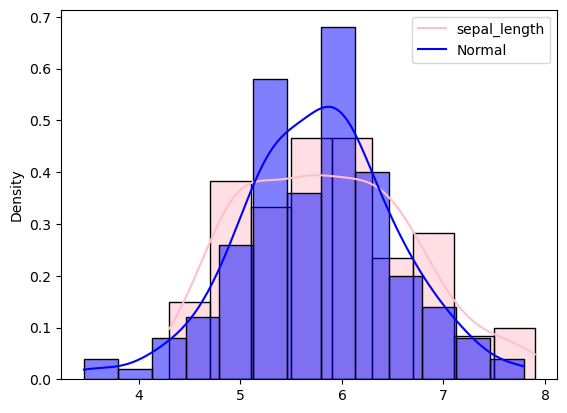

In [7]:
mu = df['sepal_length'].mean()
sigma = df['sepal_length'].std()
s = np.random.normal(loc= mu, scale= sigma, size = 150)
sns.histplot(x=df_filtered['sepal_length'], kde=True, stat="density", alpha=0.5, color='pink')
sns.histplot(x=s, kde=True, stat="density", alpha=0.5, color='blue')
plt.xlabel("")
plt.legend(['sepal_length', 'Normal'])
plt.show()

Dựa vào hình, đồ thị từ phân phối Normal sẽ có 1 đỉnh nhọn và gần giống phân phối chuẩn hơn; còn bên sepal_length thì đỉnh phẳng hơn. Vì vậy, hai đồ thị không khớp với nhau.

### Phần 3

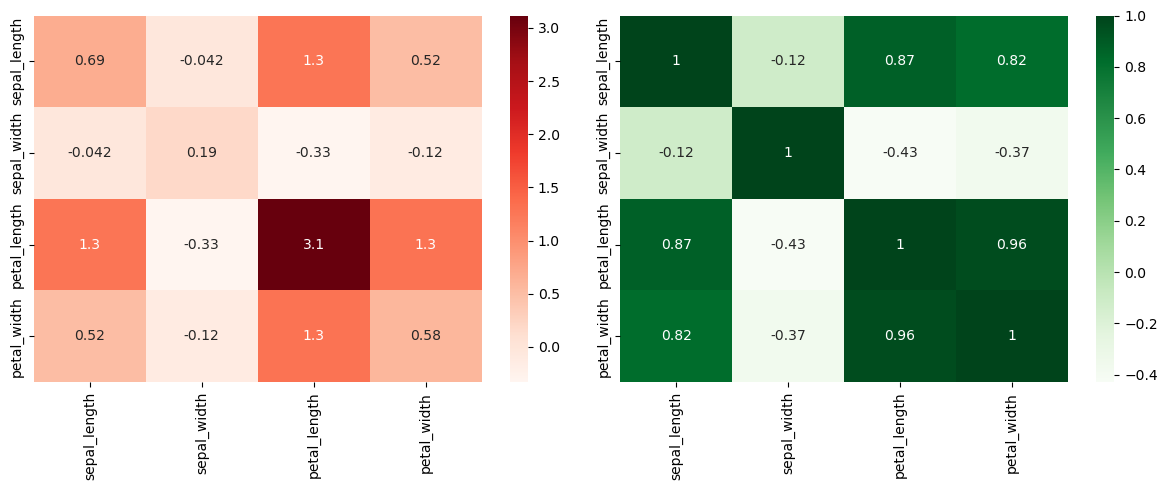

In [8]:
cov_matrix = df_filtered.cov()
cor_matrix = df_filtered.corr()
fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize= (12, 5))
sns.heatmap(cov_matrix, ax= axes[0], annot=True, cmap= 'Reds')
sns.heatmap(cor_matrix, ax= axes[1], annot=True, cmap= 'Greens')
plt.tight_layout()
plt.show()

- Cặp biến tương quan mạnh nhất là petal_length và petal_width với chỉ số correlation là 0.96.

- Có hiện tượng đa cộng tuyến do có 6 ô có chỉ số correlation trên 0.8

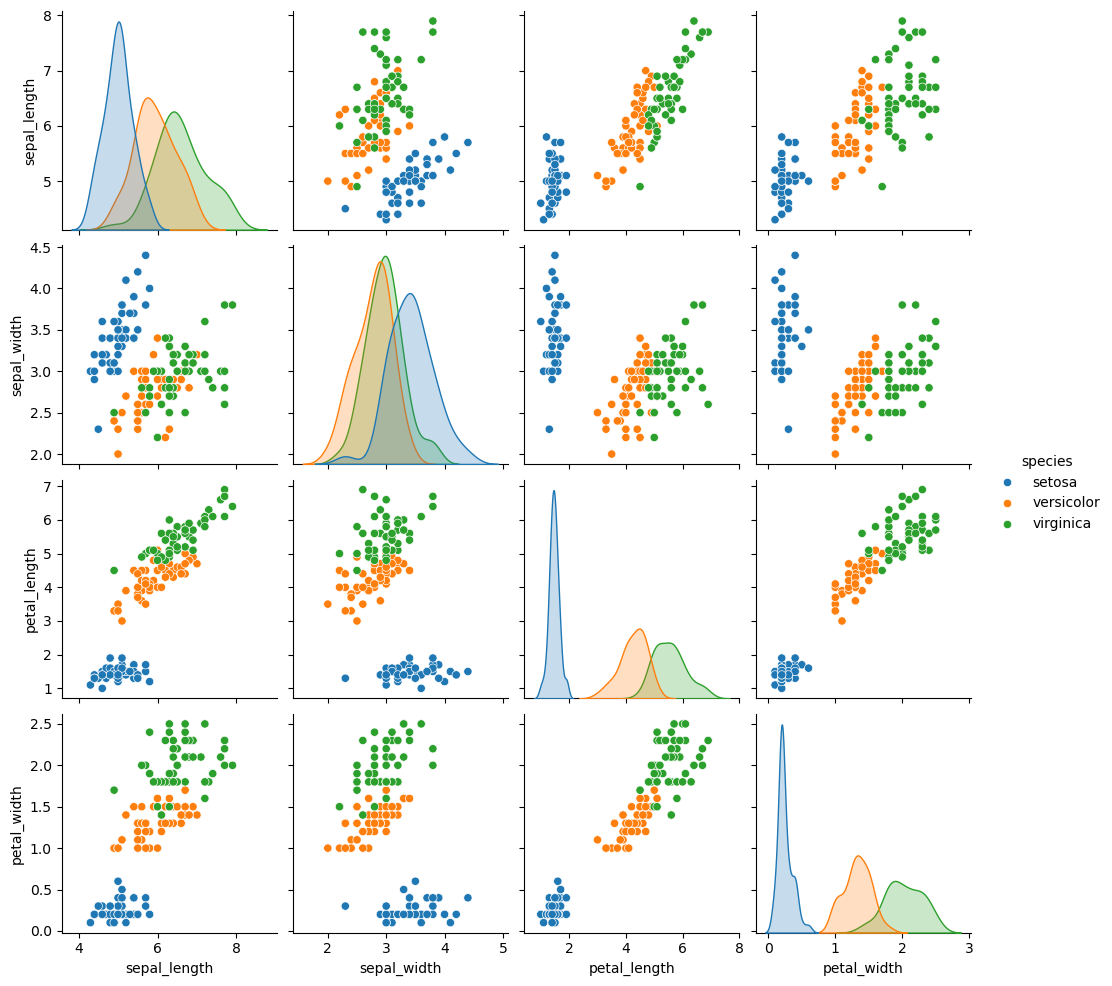

In [9]:
sns.pairplot(df, kind = 'scatter', hue= 'species')
plt.show()

Có thể thấy, nhóm versicolor và virginica có quan hệ gần gũi với nhau hơn khi một vài điểm của nhóm virginica lấn sang nhóm versicolor, còn nhóm setosa bị tách biệt hoàn toàn, tạo một cụm cách xa hai nhóm còn lại.

### Phần 4

In [10]:
P_B = 0.01
P_pos_givenB = 0.99
P_pos_givnNB = 0.05

P_pos = P_pos_givenB * P_B + P_pos_givnNB * (1 - P_B)
P_B_given_pos = P_pos_givenB * P_B / P_pos
print("P(B|+) =",round(P_B_given_pos , 4))

P(B|+) = 0.1667


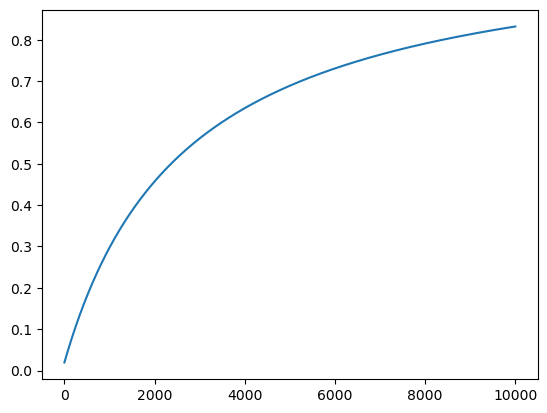

In [11]:
P_B_list = np.linspace(0.001, 0.2, num= 10000)
P_pos_list = P_pos_givenB * P_B_list + P_pos_givnNB * (1 - P_B_list)
P_B_given_pos_list = P_pos_givenB * P_B_list / P_pos_list
plt.plot(P_B_given_pos_list)
plt.show()

Khi bệnh hiếm (tỉ lệ 0.01 trở xuống) thì tỉ lệ mắc bệnh khi biết bị dương tính sẽ nằm trong khoảng rất thấp (0, 0.1). Vì vậy, tỉ lệ không mắc bệnh khi biết bị dương tính sẽ nằm trong khoảng gần như tuyệt đối (0.9-1), tương đương với việc sẽ bị "phản trực giác".